# GradNorm IsoNCA Lizard LPPN

Colab-style notebook for the first high-resolution LPPN bridge experiment from `docs/isonca_lppn_handoff.md`.

This follows the successful blogpost baseline direction: `lap_gradnorm`, a single center seed, a binary auxiliary target channel, and rotation/reflection-invariant FFT loss. The NCA grows on a `72x72` grid while the LPPN/SIREN decoder renders a padded `576x576` target image from a `512x512` Noto lizard target. As in the project's established growing LPPN route, the render is gated by the NCA living mask and NCA alpha is supervised alongside the rendered channels. Training writes a resumable checkpoint to Google Drive every 5,000 steps by default.

Two decoder variants are supported:

- `no_coords`: decoder receives only NCA state, with sub-cell coordinates zeroed.
- `coords`: decoder receives NCA state plus Cartesian sub-cell coordinates.

Run `no_coords` first. Chameleon should stay out of this notebook until the lizard path works.

In [1]:
#@title Clone repository (Colab setup)
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/IvanLudvig/Cells2Pixels.git'
BRANCH = 'isotropic'
REPO_DIR = 'Cells2Pixels'

if not Path('train.py').exists():
    if not Path(REPO_DIR).exists():
        cmd = ['git', 'clone']
        if BRANCH:
            cmd += ['--branch', BRANCH]
        cmd += [REPO_URL, REPO_DIR]
        subprocess.run(cmd, check=True)
    os.chdir(REPO_DIR)

print('cwd:', Path.cwd())

cwd: /content/Cells2Pixels


In [2]:
#@title Imports and device setup
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import random
import requests
import torch
import torch.nn.functional as F
from IPython.display import clear_output, display
from PIL import Image

from losses.invariant_image_loss import InvariantImageLoss
from models.isonca import GradNormIsoGrowingNCA
from models.siren import Siren
from training.common import make_grad_scaler, normalize_model_grads, optimizer_scheduler_step, set_seed
from utils.misc import autocast_context
from utils.render import Renderer2D

if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')
    print('CUDA is not available. The notebook will run in float32 on CPU, but training will be slow.')

print('Torch:', torch.__version__)
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

/content/Cells2Pixels/utils/icosphere.py:181: SyntaxWarning: invalid escape sequence '\ '
  indexing given by reading order             / \ / \
/content/Cells2Pixels/utils/icosphere.py:208: SyntaxWarning: invalid escape sequence '\ '
  first corners vertices, then on-edges       / \ / \
/content/Cells2Pixels/utils/icosphere.py:236: SyntaxWarning: invalid escape sequence '\ '
  given coordinates of the on-edge               / \ / \
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Torch: 2.11.0+cu128
Device: cuda:0
GPU: Tesla T4


Target: data/morphology_png/lizard.png | size: (512, 512)


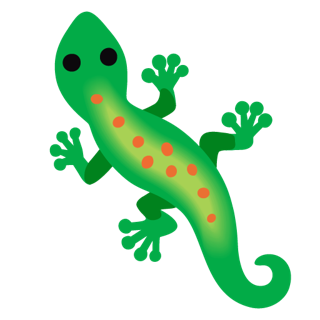

In [3]:
#@title Prepare the Noto lizard target
TARGET_IMAGE_PATH = Path('data/morphology_png/lizard.png')
LIZARD_EMOJI_CODE = '1f98e'
LIZARD_URL = f'https://github.com/googlefonts/noto-emoji/blob/main/png/512/emoji_u{LIZARD_EMOJI_CODE}.png?raw=true'


def ensure_lizard_target(path):
    path = Path(path)
    if path.exists():
        return path

    path.parent.mkdir(parents=True, exist_ok=True)
    headers = {'User-Agent': 'Cells2Pixels IsoNCA notebook'}
    response = requests.get(LIZARD_URL, headers=headers, timeout=60)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert('RGBA')
    image.save(path)
    return path


ensure_lizard_target(TARGET_IMAGE_PATH)
target_preview = Image.open(TARGET_IMAGE_PATH).convert('RGBA')
print('Target:', TARGET_IMAGE_PATH, '| size:', target_preview.size)
display(target_preview.resize((320, 320)))

In [4]:
#@title Experiment settings
SEED = 43
# Keep this experiment in float32 until the FFT loss + long NCA unroll is stable.
# AMP/fp16 overflows gradients at step 0 on Colab/T4 for this setup.
PRECISION = torch.float32

# 512 target + 32px border on each side = 576 render pixels. With scale 8, the NCA grid is 72x72.
IMAGE_SIZE = (512, 512)
PADDING = (32, 32)
SCALE_FACTOR = 8

# Blogpost successful baseline values.
CHANNELS = 16
FC_DIM = 128
UPDATE_PROB = 0.5
OUTPUT_TYPE = 's'  # use 'z' to decode perception features instead of raw state

# LPPN decoder. out_features is inferred from the loss target: RGBA + binary aux = 5.
SIREN_HIDDEN = 96
SIREN_LAYERS = 2
SIREN_FREQUENCIES = 1

# Notebook defaults are meant as a first smoke/train run, not a final-quality 50k-step run.
TRAIN_STEPS = 50000  #@param {type: 'integer'}
BATCH_SIZE = 2  #@param {type: 'integer'}
POOL_SIZE = 256  #@param {type: 'integer'}
# Match the successful blogpost lizard horizon. Short 16-32 step rollouts
# bias this setup toward a compact center blob instead of a full-body lizard.
STEP_RANGE = (64, 96)
EARLY_SEED_STEPS = 4000
SUMMARY_INTERVAL = 500
CHECKPOINT_INTERVAL = 5000
RESUME_FROM_CHECKPOINT = True
USE_GOOGLE_DRIVE = True  # Persist checkpoints across Colab runtime limits.

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
    except ImportError:
        CHECKPOINT_ROOT = Path('notebook_runs')
        print('Google Drive is unavailable; checkpoints will be stored locally.')
    else:
        drive.mount('/content/drive')
        CHECKPOINT_ROOT = Path('/content/drive/MyDrive/Cells2Pixels/notebook_runs')
else:
    CHECKPOINT_ROOT = Path('notebook_runs')
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
print('Checkpoint root:', CHECKPOINT_ROOT)

# Keep damage off until the NCA has a nonzero gradient and can grow reliably.
DAMAGE_ENABLED = False
DAMAGE_RATE = 6

# Match the established growing_2d LPPN route: gate the render with the
# automaton living mask and supervise NCA alpha in the image objective.
SUPERVISE_NCA_ALPHA = True

LR = 1e-3
LR_BASE = 1e-5
LR_SCHEDULER = 'cyclic'
LR_CYCLE_STEP_UP = 2000
LR_DECAY_GAMMA = 0.3
LR_DECAY_STEPS = [max(1, TRAIN_STEPS // 2), max(2, 4 * TRAIN_STEPS // 5)]
OVERFLOW_WEIGHT = 10.0
DIFF_WEIGHT = 10.0

EVAL_STEPS = 96
ANGLES = [30.0, 45.0, 60.0]
RUN_VARIANTS = ['no_coords']  # Run the coordinate decoder only after this baseline learns.

set_seed(SEED)

Mounted at /content/drive
Checkpoint root: /content/drive/MyDrive/Cells2Pixels/notebook_runs


In [5]:
#@title Build/render helpers
def make_loss():
    return InvariantImageLoss(
        target_path=str(TARGET_IMAGE_PATH),
        image_size=IMAGE_SIZE,
        padding=PADDING,
        premultiply_alpha=True,
        aux_type='binary',
        mirror=True,
        sharpen=True,
        l2_weight=1.0,
        include_nca_alpha=SUPERVISE_NCA_ALPHA,
        device=device,
    )


def make_seed(model, n, h, w):
    return model.seed(n, h, w).to(device=device, dtype=PRECISION)


def build_variant(name):
    loss_fn = make_loss()
    model = GradNormIsoGrowingNCA(
        channels=CHANNELS,
        fc_dim=FC_DIM,
        update_prob=UPDATE_PROB,
        device=device,
        precision=PRECISION,
    ).to(device)

    nca_output_dim = model.channels
    if OUTPUT_TYPE == 'z':
        nca_output_dim *= model.perception_kernels

    siren = Siren(
        in_features=nca_output_dim,
        coord_dim=2,
        out_features=loss_fn.channel_n,
        hidden_features=SIREN_HIDDEN,
        hidden_layers=SIREN_LAYERS,
        outermost_linear=True,
        fx='linear',
        activation='sin',
        num_frequencies=SIREN_FREQUENCIES,
        first_omega_0=10.0,
        hidden_omega_0=10.0,
        disable=False,
        disable_coords=(name == 'no_coords'),
    ).to(device)

    renderer = Renderer2D(scale_factor=SCALE_FACTOR, padding='circular', fs_shader='vanilla', precision=PRECISION)
    grid_size = (loss_fn.grid_size[0] // renderer.scale_factor, loss_fn.grid_size[1] // renderer.scale_factor)
    print(name, '| rendered grid:', loss_fn.grid_size, '| NCA grid:', grid_size, '| channels:', loss_fn.channel_n)
    return model, siren, loss_fn, renderer, grid_size


def render_channels(model, siren, renderer, state, perception=None):
    x_render = state if OUTPUT_TYPE == 's' or perception is None else perception
    image = renderer.render(
        x_render.to(torch.float32).permute(0, 2, 3, 1),
        siren,
        None,
        fs_shader='vanilla',
        hard_clamp=False,
    )
    x_up = F.interpolate(
        state.to(torch.float32),
        size=image.shape[1:3],
        mode='bilinear',
        align_corners=False,
    )
    living_mask = model.get_living_mask(x_up).to(image.dtype).permute(0, 2, 3, 1)
    return image.to(torch.float32) * living_mask


def composite_rgba(image):
    image = np.asarray(image)
    rgb = np.clip(image[..., :3], 0.0, 1.0)
    alpha = np.clip(image[..., 3:4], 0.0, 1.0)
    return rgb + (1.0 - alpha)


def damage_mask(n, h, w):
    yy = torch.linspace(-1.0, 1.0, h, device=device, dtype=torch.float32)[None, :, None]
    xx = torch.linspace(-1.0, 1.0, w, device=device, dtype=torch.float32)[None, None, :]
    center = torch.empty(n, 2, 1, 1, device=device).uniform_(-0.5, 0.5)
    radius = torch.empty(n, 1, 1, device=device).uniform_(0.12, 0.4)
    mask = ((xx - center[:, 0]) ** 2 + (yy - center[:, 1]) ** 2 < radius ** 2).float()
    return mask[:, None]


def reset_dead_samples(model, x):
    if len(x) <= 1:
        return x
    dead = (x[1:, 3:4].sum(dim=(1, 2, 3), keepdim=True) < 1e-6).to(x.dtype)
    if dead.any():
        seed = make_seed(model, len(x) - 1, x.shape[-2], x.shape[-1])
        x[1:] = dead * seed + (1.0 - dead) * x[1:]
    return x


def make_scheduler(optimizer):
    if LR_SCHEDULER == 'cyclic':
        return torch.optim.lr_scheduler.CyclicLR(
            optimizer,
            base_lr=LR_BASE,
            max_lr=LR,
            step_size_up=LR_CYCLE_STEP_UP,
            mode='triangular2',
            cycle_momentum=False,
        )
    return torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=LR_DECAY_STEPS, gamma=LR_DECAY_GAMMA)


def total_grad_norm(module):
    norms = [p.grad.detach().float().norm() for p in module.parameters() if p.grad is not None]
    if not norms:
        return torch.zeros((), device=device)
    return torch.linalg.vector_norm(torch.stack(norms))


def variant_output_dir(name):
    path = CHECKPOINT_ROOT / f'isonca_lizard_lppn_{name}'
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_training_checkpoint(name, step, model, siren, optimizer, scheduler, scaler, pool, history):
    path = variant_output_dir(name) / 'latest.pt'
    temporary_path = path.with_suffix('.tmp')
    checkpoint = {
        'version': 1,
        'variant': name,
        'step': step,
        'model': model.state_dict(),
        'siren': siren.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'pool': pool.detach().cpu(),
        'history': history,
        'torch_rng_state': torch.get_rng_state(),
        'cuda_rng_state_all': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        'numpy_rng_state': np.random.get_state(),
        'python_rng_state': random.getstate(),
        'grid_size': tuple(pool.shape[-2:]),
        'pool_size': len(pool),
    }
    torch.save(checkpoint, temporary_path)
    os.replace(temporary_path, path)
    print(f'checkpoint saved: {path} (step {step})')


def restore_training_checkpoint(name, model, siren, optimizer, scheduler, scaler, pool):
    path = variant_output_dir(name) / 'latest.pt'
    if not RESUME_FROM_CHECKPOINT or not path.exists():
        return 0, pool, []

    checkpoint = torch.load(path, map_location=device, weights_only=False)
    if checkpoint.get('variant') != name:
        raise ValueError(f'Checkpoint variant mismatch: expected {name}, found {checkpoint.get("variant")}')
    restored_pool = checkpoint['pool'].to(device=device, dtype=PRECISION)
    if restored_pool.shape != pool.shape:
        raise ValueError(f'Checkpoint pool shape {tuple(restored_pool.shape)} does not match {tuple(pool.shape)}')

    model.load_state_dict(checkpoint['model'])
    siren.load_state_dict(checkpoint['siren'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    scaler.load_state_dict(checkpoint.get('scaler', {}))
    torch.set_rng_state(checkpoint['torch_rng_state'].cpu())
    if torch.cuda.is_available() and checkpoint.get('cuda_rng_state_all') is not None:
        torch.cuda.set_rng_state_all([state.cpu() for state in checkpoint['cuda_rng_state_all']])
    np.random.set_state(checkpoint['numpy_rng_state'])
    random.setstate(checkpoint['python_rng_state'])

    start_step = int(checkpoint['step']) + 1
    history = checkpoint.get('history', [])
    print(f'resumed: {path} (next step {start_step})')
    return start_step, restored_pool, history

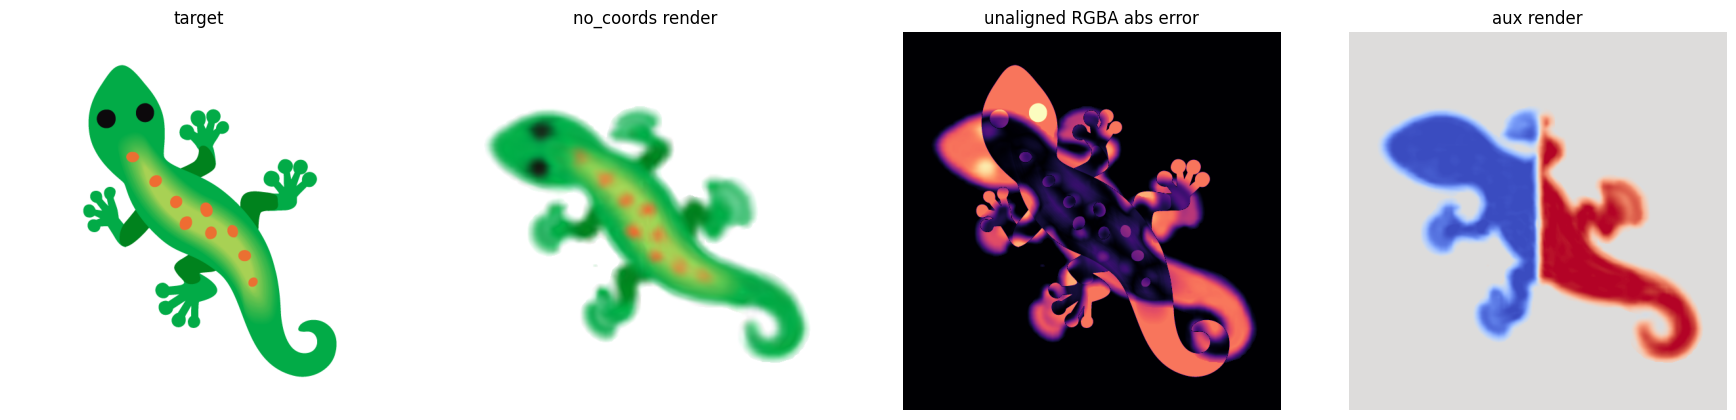

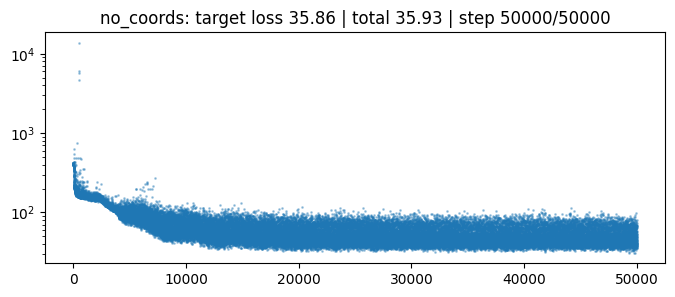

{'step': 50000, 'loss': 35.93070983886719, 'target': 35.85627746582031, 'overflow': 0.005164541769772768, 'diff': 0.0022786823101341724, 'model_grad': 670.7275390625, 'siren_grad': 111.9917984008789, 'lr': 1.0241578369140626e-05, 'step_n': 95}
checkpoint saved: /content/drive/MyDrive/Cells2Pixels/notebook_runs/isonca_lizard_lppn_no_coords/latest.pt (step 50000)
saved: /content/drive/MyDrive/Cells2Pixels/notebook_runs/isonca_lizard_lppn_no_coords


In [6]:
#@title Train variants
def train_variant(name):
    set_seed(SEED)
    model, siren, loss_fn, renderer, grid_size = build_variant(name)
    with torch.no_grad():
        pool = make_seed(model, POOL_SIZE, grid_size[0], grid_size[1])

    optimizer_lr = LR_BASE if LR_SCHEDULER == 'cyclic' else LR
    optimizer = torch.optim.Adam(list(model.parameters()) + list(siren.parameters()), lr=optimizer_lr)
    scheduler = make_scheduler(optimizer)
    scaler = make_grad_scaler(device, PRECISION)
    start_step, pool, history = restore_training_checkpoint(
        name, model, siren, optimizer, scheduler, scaler, pool
    )

    model.train()
    siren.train()
    for step in range(start_step, TRAIN_STEPS + 1):
        with torch.no_grad():
            batch_idx = np.random.choice(len(pool), BATCH_SIZE, replace=False)
            x = pool[batch_idx].clone()
            seed_rate = 1 if step < EARLY_SEED_STEPS else 6
            if step % seed_rate == 0:
                x[:1] = make_seed(model, 1, grid_size[0], grid_size[1])
            if DAMAGE_ENABLED and step % DAMAGE_RATE == 0:
                x[-1:] *= 1.0 - damage_mask(1, grid_size[0], grid_size[1]).to(dtype=PRECISION)
            x = reset_dead_samples(model, x)

        step_n = np.random.randint(*STEP_RANGE)
        diff_loss = torch.zeros((), device=device, dtype=torch.float32)
        z = None
        with autocast_context(device, PRECISION):
            for _ in range(step_n):
                prev_x = x
                x, z = model(x)
                diff_loss = diff_loss + (x.to(torch.float32) - prev_x.to(torch.float32)).abs().mean()

        rendered = render_channels(model, siren, renderer, x, z).permute(0, 3, 1, 2)
        x_up = F.interpolate(
            x.to(torch.float32),
            size=rendered.shape[-2:],
            mode='bilinear',
            align_corners=False,
        )
        target_loss, target_log, _ = loss_fn(
            {'generated_images': rendered, 'alpha': x_up[:, 3:4]},
            return_summary=False,
        )
        overflow_loss = (x.to(torch.float32) - x.to(torch.float32).clamp(-2.0, 2.0)).square().mean()
        loss = (
            target_loss
            + OVERFLOW_WEIGHT * overflow_loss
            + DIFF_WEIGHT * diff_loss / max(step_n, 1)
        )
        if not torch.isfinite(loss):
            raise ValueError(f'{name} loss is NaN or Inf at step {step}')

        optimizer.zero_grad(set_to_none=True)
        if PRECISION == torch.float16:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if PRECISION == torch.float16:
            scaler.unscale_(optimizer)

        model_grad = total_grad_norm(model)
        siren_grad = total_grad_norm(siren)
        if not torch.isfinite(model_grad) or not torch.isfinite(siren_grad):
            raise ValueError(f'non-finite gradients at step {step}: model={model_grad.item()}, siren={siren_grad.item()}')
        with torch.no_grad():
            normalize_model_grads(model)
            optimizer_scheduler_step(optimizer, scheduler, scaler, PRECISION)
            pool[batch_idx] = x.detach().to(dtype=pool.dtype)

        row = {
            'step': step,
            'loss': float(loss.detach().cpu()),
            'target': float(target_loss.detach().cpu()),
            'overflow': float(overflow_loss.detach().cpu()),
            'diff': float((diff_loss / max(step_n, 1)).detach().cpu()),
            'model_grad': float(model_grad.detach().cpu()),
            'siren_grad': float(siren_grad.detach().cpu()),
            'lr': float(optimizer.param_groups[0]['lr']),
            'step_n': int(step_n),
        }
        history.append(row)

        if step % SUMMARY_INTERVAL == 0:
            clear_output(wait=True)
            target_rgba = loss_fn.target_image[0, :4].detach().cpu().permute(1, 2, 0).numpy()
            image_rgba = rendered[0, :4].detach().cpu().permute(1, 2, 0).numpy()
            aux_image = rendered[0, 4].detach().cpu().numpy() if rendered.shape[1] > 4 else None

            fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
            axes[0].imshow(composite_rgba(target_rgba))
            axes[0].set_title('target')
            axes[1].imshow(composite_rgba(image_rgba))
            axes[1].set_title(f'{name} render')
            axes[2].imshow(np.abs(composite_rgba(target_rgba) - composite_rgba(image_rgba)).mean(-1), cmap='magma')
            axes[2].set_title('unaligned RGBA abs error')
            if aux_image is None:
                axes[3].axis('off')
            else:
                axes[3].imshow(aux_image, cmap='coolwarm', vmin=-0.5, vmax=0.5)
                axes[3].set_title('aux render')
            for ax in axes:
                ax.axis('off')
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(8, 3))
            plt.plot([r['target'] for r in history], '.', ms=2, alpha=0.35)
            plt.yscale('log')
            plt.title(f"{name}: target loss {row['target']:.4g} | total {row['loss']:.4g} | step {step}/{TRAIN_STEPS}")
            plt.show()
            print(row)

        if step > 0 and step % CHECKPOINT_INTERVAL == 0:
            save_training_checkpoint(
                name, step, model, siren, optimizer, scheduler, scaler, pool, history
            )

    out_dir = variant_output_dir(name)
    torch.save(model.state_dict(), out_dir / 'model.pth')
    torch.save(siren.state_dict(), out_dir / 'siren.pth')
    settings = {
        'seed': SEED,
        'precision': str(PRECISION),
        'image_size': IMAGE_SIZE,
        'padding': PADDING,
        'scale_factor': SCALE_FACTOR,
        'channels': CHANNELS,
        'fc_dim': FC_DIM,
        'update_prob': UPDATE_PROB,
        'output_type': OUTPUT_TYPE,
        'train_steps': TRAIN_STEPS,
        'lr': LR,
        'lr_base': LR_BASE,
        'lr_scheduler': LR_SCHEDULER,
        'lr_cycle_step_up': LR_CYCLE_STEP_UP,
        'lr_decay_gamma': LR_DECAY_GAMMA,
        'lr_decay_steps': LR_DECAY_STEPS,
        'batch_size': BATCH_SIZE,
        'pool_size': POOL_SIZE,
        'step_range': STEP_RANGE,
        'damage_enabled': DAMAGE_ENABLED,
        'damage_rate': DAMAGE_RATE,
        'supervise_nca_alpha': SUPERVISE_NCA_ALPHA,
        'checkpoint_interval': CHECKPOINT_INTERVAL,
        'resume_from_checkpoint': RESUME_FROM_CHECKPOINT,
        'checkpoint_root': str(CHECKPOINT_ROOT),
        'target_path': str(TARGET_IMAGE_PATH),
    }
    torch.save({'history': history, 'settings': settings}, out_dir / 'run_meta.pth')
    print('saved:', out_dir)
    return {
        'name': name,
        'model': model.eval(),
        'siren': siren.eval(),
        'loss_fn': loss_fn,
        'renderer': renderer,
        'grid_size': grid_size,
        'history': history,
        'path': out_dir,
    }


variants = {}
for variant_name in RUN_VARIANTS:
    variants[variant_name] = train_variant(variant_name)

In [7]:
#@title Equivariance metrics
def rollout(model, x, steps):
    z = None
    with autocast_context(device, PRECISION):
        for _ in range(steps):
            x, z = model(x)
    return x, z


def rel_l2(a, b):
    return torch.linalg.vector_norm((a - b).reshape(a.shape[0], -1), dim=1) / (
        torch.linalg.vector_norm(b.reshape(b.shape[0], -1), dim=1) + 1e-8
    )


def affine_rotate_nchw(x, angle_deg):
    angle = torch.tensor(angle_deg * torch.pi / 180.0, device=x.device, dtype=x.dtype)
    c = torch.cos(angle)
    s = torch.sin(angle)
    theta = torch.zeros(x.shape[0], 2, 3, device=x.device, dtype=x.dtype)
    theta[:, 0, 0] = c
    theta[:, 0, 1] = -s
    theta[:, 1, 0] = s
    theta[:, 1, 1] = c
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, mode='bilinear', padding_mode='zeros', align_corners=False)


def affine_rotate_nhwc(image, angle_deg):
    return affine_rotate_nchw(image.permute(0, 3, 1, 2), angle_deg).permute(0, 2, 3, 1)


@torch.no_grad()
def evaluate_variant(variant, steps=EVAL_STEPS, angles=ANGLES):
    model = variant['model']
    siren = variant['siren']
    renderer = variant['renderer']
    old_update_prob = model.update_prob
    model.update_prob = 1.0
    rows = []
    visuals = {}
    try:
        h, w = variant['grid_size']
        x0 = make_seed(model, 1, h, w)
        x_base, z_base = rollout(model, x0, steps)
        image_base = render_channels(model, siren, renderer, x_base, z_base)

        def add_result(kind, label, state, expected_state, image, expected_image):
            err = (image - expected_image).abs()
            rows.append({
                'kind': kind,
                'transform': label,
                'state_mae': (state - expected_state).abs().mean().item(),
                'state_rel_l2': rel_l2(state, expected_state).mean().item(),
                'render_mae': err[..., :4].mean().item(),
                'render_rel_l2': rel_l2(image[..., :4], expected_image[..., :4]).mean().item(),
                'aux_mae': err[..., 4:5].mean().item() if image.shape[-1] > 4 else 0.0,
            })
            visuals[label] = {
                'base': image_base.detach().cpu(),
                'transformed_seed': image.detach().cpu(),
                'transformed_output': expected_image.detach().cpu(),
                'error': err.detach().cpu(),
            }

        for k in (1, 2, 3):
            x_t0 = torch.rot90(x0, k, dims=(-2, -1))
            x_t, z_t = rollout(model, x_t0, steps)
            image_t = render_channels(model, siren, renderer, x_t, z_t)
            add_result(
                'exact_rotation',
                f'rot{k * 90}',
                x_t,
                torch.rot90(x_base, k, dims=(-2, -1)),
                image_t,
                torch.rot90(image_base, k, dims=(-3, -2)),
            )

        for label, state_dims, image_dims in (('flip_x', (-1,), (-2,)), ('flip_y', (-2,), (-3,))):
            x_t0 = torch.flip(x0, dims=state_dims)
            x_t, z_t = rollout(model, x_t0, steps)
            image_t = render_channels(model, siren, renderer, x_t, z_t)
            add_result('reflection', label, x_t, torch.flip(x_base, dims=state_dims), image_t, torch.flip(image_base, dims=image_dims))

        for angle in angles:
            x_t0 = affine_rotate_nchw(x0, angle)
            x_t, z_t = rollout(model, x_t0, steps)
            image_t = render_channels(model, siren, renderer, x_t, z_t)
            add_result('interpolated_rotation', f'rot{angle:g}', x_t, affine_rotate_nchw(x_base, angle), image_t, affine_rotate_nhwc(image_base, angle))
    finally:
        model.update_prob = old_update_prob
    return rows, visuals


results = {}
visuals = {}
for name, variant in variants.items():
    rows, vis = evaluate_variant(variant)
    results[name] = rows
    visuals[name] = vis
    print('\n' + name)
    print('kind | transform | state_mae | state_rel_l2 | render_mae | render_rel_l2 | aux_mae')
    for row in rows:
        print(f"{row['kind']} | {row['transform']} | {row['state_mae']:.3e} | {row['state_rel_l2']:.3e} | {row['render_mae']:.3e} | {row['render_rel_l2']:.3e} | {row['aux_mae']:.3e}")


no_coords
kind | transform | state_mae | state_rel_l2 | render_mae | render_rel_l2 | aux_mae
exact_rotation | rot90 | 5.150e-04 | 2.755e-03 | 2.918e-04 | 2.224e-03 | 5.553e-04
exact_rotation | rot180 | 3.917e-04 | 2.124e-03 | 2.014e-04 | 1.692e-03 | 4.808e-04
exact_rotation | rot270 | 5.150e-04 | 2.755e-03 | 2.918e-04 | 2.224e-03 | 5.553e-04
reflection | flip_x | 4.562e-04 | 2.564e-03 | 2.577e-04 | 2.108e-03 | 5.093e-04
reflection | flip_y | 3.863e-04 | 2.155e-03 | 2.231e-04 | 1.872e-03 | 4.159e-04
interpolated_rotation | rot30 | 3.680e-01 | 1.068e+00 | 2.338e-01 | 9.112e-01 | 1.772e-01
interpolated_rotation | rot45 | 3.494e-01 | 1.002e+00 | 2.642e-01 | 9.999e-01 | 1.849e-01
interpolated_rotation | rot60 | 3.680e-01 | 1.068e+00 | 2.338e-01 | 9.111e-01 | 1.772e-01


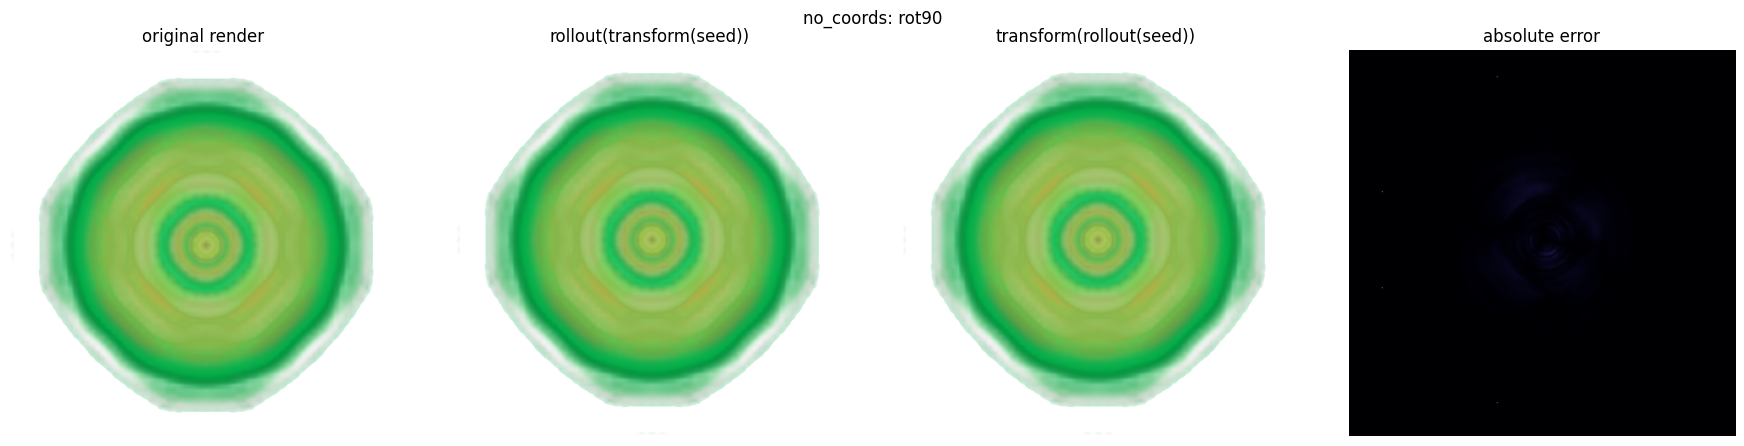

In [8]:
#@title Visual comparison grids
def show_grid(variant_name, transform='rot45'):
    item = visuals[variant_name][transform]
    titles = ['original render', 'rollout(transform(seed))', 'transform(rollout(seed))', 'absolute error']
    tensors = [item['base'], item['transformed_seed'], item['transformed_output'], item['error']]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    for ax, title, tensor in zip(axes, titles, tensors):
        img = tensor[0].numpy()
        if title == 'absolute error':
            ax.imshow(img[..., :4].mean(axis=-1), cmap='magma')
        else:
            ax.imshow(composite_rgba(img[..., :4]))
        ax.set_title(title)
        ax.axis('off')
    fig.suptitle(f'{variant_name}: {transform}')
    plt.tight_layout()
    plt.show()


for name in visuals:
    default_transform = 'rot90' if 'rot90' in visuals[name] else next(iter(visuals[name]))
    show_grid(name, default_transform)

In [9]:
# Try other transforms after the previous cell runs:
# show_grid('no_coords', 'flip_x')
# show_grid('no_coords', 'rot90')
# show_grid('no_coords', 'rot45')
# show_grid('coords', 'rot90')